# Market Risk Statistical Validation Framework

### Do the standard Value-at-Risk models actually hold up out of sample? A classical-statistics audit on NIFTY 50.

---

## Aim

Take five VaR models a risk desk actually uses — Historical, Parametric
Normal, Parametric Student-t, EWMA (RiskMetrics) and GARCH(1,1) — and subject
each one to the same regulatory-style validation battery on six years of
NIFTY 50 data:

1. **Kupiec (1995) Proportion-of-Failures** — did the model breach the right
   NUMBER of times?
2. **Christoffersen (1998) independence** — did those breaches arrive at
   independent TIMES, or in bursts?
3. **Christoffersen joint conditional coverage** — the two together, which is
   the test a model has to survive to be usable.

Every estimate is produced walk-forward out of sample: VaR for day *t* is fitted
on days *t-250 … t-1* and then tested against day *t*. Nothing that describes
day *t* has seen day *t*.

## Motivation — why I built this

Most VaR write-ups stop at *computing* a number. That is the easy half. The
question a risk function is actually asked is **"can we rely on this number?"**,
and that is a hypothesis-testing problem, not an estimation problem.

Three things pushed me to build it this way:

* **A single p-value hides the failure that matters.** A model can breach
  exactly 5% of the time and still be dangerous if every breach lands in the
  same fortnight. Kupiec is blind to that; only the independence test sees it.
  So the whole battery is reported per model, not one headline number.

* **Look-ahead bias is silent.** While building the volatility-regime section I
  found that labelling a day "high volatility" from a rolling window that
  *includes that day's own return* fabricates statistical significance. On
  purely random data with no regime structure at all, the leaky labelling
  rejects equal variance decisively while the correct lagged labelling finds
  nothing. Section 3 keeps both versions side by side so the size of the bug is
  visible instead of merely described. That single `.shift(1)` is the most
  important line in the repository.

* **Basel moved on, so the project should too.** The FRTB replaced 99% VaR with
  97.5% Expected Shortfall. Section 10 reproduces the reason: VaR says nothing
  about how bad a breach is, and it is not sub-additive. ES is. Section 9b
  reproduces the other half of "moving on": the traffic-light capital
  multiplier a bank actually applies to a backtest, not just the p-value.

## Scope

Deliberately classical throughout — distributions, maximum likelihood,
hypothesis tests, OLS with heteroskedasticity-robust errors, likelihood-ratio
backtests. GARCH(1,1) (Section 8b) is included on the same terms: it is a
fully specified likelihood fit by MLE, with two estimated parameters instead
of EWMA's one assumed one — still classical inference, not machine learning.
No machine learning anywhere. The engine lives in `risk_utils.py` and is shared with the Streamlit
dashboard, so no number is implemented twice.

## Structure

| # | Section | Question answered |
|---|---------|-------------------|
| 1 | Data & Log Returns | What are we working with? |
| 2 | Distribution Analysis | Normal or fat-tailed? |
| 3 | Volatility Regimes + the look-ahead trap | Does risk cluster, and can I measure that without cheating? |
| 4 | Market Model Regression | How much of each stock is systematic risk? |
| 5 | Stress-Day Flagging | What is the Type I / Type II trade-off of a simple alarm? |
| 6 | Value at Risk (3 distributional methods) | What is the one-day loss estimate? |
| 7 | Out-of-Sample Backtesting: Kupiec | Is the breach COUNT right? |
| 8 | EWMA VaR | Does a volatility-reactive model fix the timing? |
| 8b | GARCH(1,1) VaR | Does estimating persistence beat a fixed decay? |
| 9 | Christoffersen: independence & joint coverage | Is the breach TIMING right? |
| 9b | Basel Traffic-Light Zones | What capital multiplier follows from the backtest? |
| 10 | Expected Shortfall | How bad is it *beyond* VaR? |
| 11 | Conclusions | What survived? |

> **Reproducibility.** This notebook downloads price data live from Yahoo
> Finance every time it runs -- there is no committed data snapshot in this
> repo, so the exact end date (and therefore some figures) can shift slightly
> between runs as new trading days become available. There is also no
> automated test suite yet -- an honest limitation, not a hidden one.

In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.stats as stats 

import risk_utils as ru 

plt.rcParams["figure.figsize"] = (9, 4.5) 
pd.set_option("display.float_format", lambda x: f"{x:,.5f}") 

def format_pvalue(p): 
    if pd.isna(p):
        return "N/A"
    if p == 0:  
        return "<1e-300" 
    if p < 0.0001:
        return f"{p:.2e}"
    return f"{p:.4f}"


## Configuration

**Market Index:** NIFTY 50 (`^NSEI`)

**Stocks:** `RELIANCE.NS`, `TCS.NS`, `HDFCBANK.NS`, `INFY.NS` — four large-caps across different sectors, used to compare market sensitivity (beta).


In [29]:
MARKET_TICKER = "^NSEI"
STOCK_TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS"]
START, END = "2019-01-01", "2024-12-31"

all_tickers = [MARKET_TICKER] + STOCK_TICKERS

# Snapshot-first: reads data/prices.csv if it exists, and only calls Yahoo
# otherwise. This repo has no committed snapshot, so every run downloads live --
# meaning the exact end date, and any figure sensitive to the most recent days,
# can differ slightly between runs. The snapshot-first check is still here so
# that dropping a data/prices.csv file in later would work without code changes.
prices = ru.load_prices(all_tickers, START, END)
prices = prices.rename(columns={MARKET_TICKER: "NIFTY50"})

print(f"{len(prices)} trading days, {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Source: {'data/prices.csv snapshot' if ru.DEFAULT_SNAPSHOT.exists() else 'live Yahoo Finance download'}")
prices.tail()

1480 trading days, 2019-01-01 to 2024-12-30
Source: live Yahoo Finance download


,NIFTY50,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS
Date,,,,,
2024-12-23,"23,753.44922","1,211.83472","3,872.73779",874.03430,"1,829.40137"
2024-12-24,"23,727.65039","1,212.28076","3,892.48169",872.62683,"1,814.90344"
2024-12-26,"23,750.19922","1,206.13391","3,882.79614",869.05988,"1,813.33484"
2024-12-27,"23,813.40039","1,210.59546","3,878.83789",872.69965,"1,822.22375"
2024-12-30,"23,644.90039","1,200.33398","3,873.20288",862.82373,"1,812.00391"


## 1. Data & Log Returns

$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are used because they are additive across time, making them convenient for statistical analysis.


In [30]:
returns = ru.log_returns(prices)
returns.tail()


,NIFTY50,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS
Date,,,,,
2024-12-23,0.00701,0.01401,-0.00288,0.01652,0.00112
2024-12-24,-0.00109,0.00037,0.00509,-0.00161,-0.00796
2024-12-26,0.00095,-0.00508,-0.00249,-0.00410,-0.00086
2024-12-27,0.00266,0.00369,-0.00102,0.00418,0.00489
2024-12-30,-0.00710,-0.00851,-0.00145,-0.01138,-0.00562


In [31]:
stats_table = returns.apply(ru.descriptive_stats).T
stats_table


,mean_daily,std_daily,annualised_vol,skewness,excess_kurtosis
NIFTY50,0.00051,0.01166,0.18509,-1.58831,21.87987
RELIANCE.NS,0.00059,0.01843,0.29253,0.11755,9.86298
TCS.NS,0.00059,0.01524,0.24198,-0.12683,4.61781
HDFCBANK.NS,0.00035,0.01652,0.26231,-0.36129,9.45724
INFY.NS,0.00080,0.01765,0.28023,-0.78767,12.15833


### Observations
* RELIANCE is the most volatile stock (29.25% annualised), NIFTY 50 the least (18.51%).
* All series show negative skew and heavy tails — big losses happen more often than a Normal curve would predict.

### Conclusion
Returns are not Normally distributed, especially in the tails. Next, we compare Normal vs Student-t fits directly.


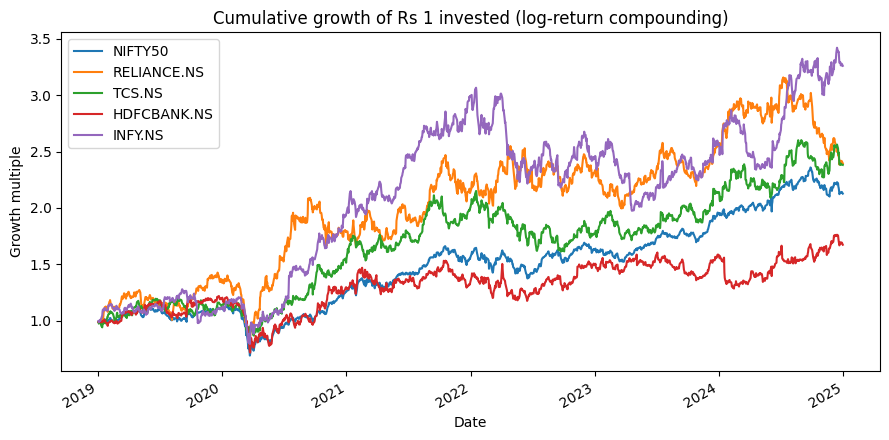

In [32]:
fig, ax = plt.subplots()
np.exp(returns.cumsum()).plot(ax=ax)
ax.set_title("Cumulative growth of Rs 1 invested (log-return compounding)")
ax.set_ylabel("Growth multiple")
plt.tight_layout()
plt.show()

### Observations
* INFY grew the most (~₹3.3 per ₹1 invested), HDFCBANK the least (~₹1.7), over 2019–2024.
* All four assets crash together in early 2020 (COVID shock).

### Conclusion
Higher growth doesn't mean lower risk — INFY grew the most but is also one of the more volatile stocks.


## 2. Distribution Analysis — Normal vs Student-t

**Question:** Are returns actually Normally distributed, or fat-tailed?

If fat-tailed, a Normal-distribution VaR model will *understate* the risk of extreme losses.


In [33]:
market_returns = returns["NIFTY50"]

normal_params = ru.fit_normal(market_returns)
t_params = ru.fit_student_t(market_returns)
jb_result = ru.goodness_of_fit_normal(market_returns)

print("Normal fit:", normal_params)
print("Student-t fit:", t_params, ) #lower df = fatter tails than normal

print("\nJarque-Bera normality test")
print(f"  Statistic : {jb_result['jarque_bera_stat']:.4f}")
print(f"  p-value   : {format_pvalue(jb_result['p_value'])}")
print(f"  Reject H0 : {jb_result['reject_normality_at_5pct']}")

Normal fit: {'loc': np.float64(0.000512126255157476), 'scale': np.float64(0.011655480155777533)}
Student-t fit: {'df': np.float64(3.1514170248349678), 'loc': np.float64(0.0009589007617830125), 'scale': np.float64(0.006919161092155353)}

Jarque-Bera normality test
  Statistic : 30021.6783
  p-value   : <1e-300
  Reject H0 : True


### Observations
* NIFTY 50 returns clearly fail the normality test (Jarque-Bera, p < 10⁻³⁰⁰).
* The Student-t fit has only ~3.15 degrees of freedom → substantially heavier tails than Normal.

### Conclusion
Returns are non-Normal with fat tails — a Normal-based VaR model will likely understate extreme-loss risk.


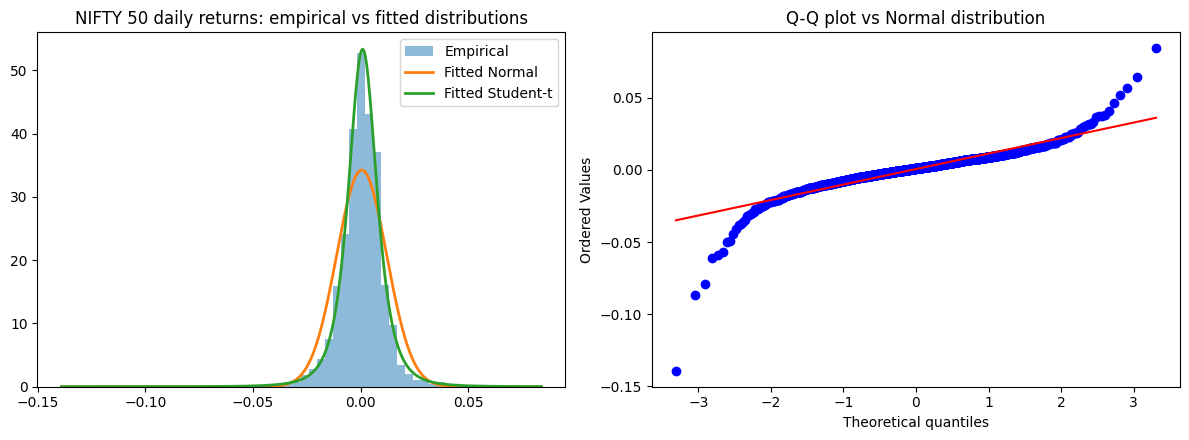

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram vs fitted densities
x = np.linspace(market_returns.min(), market_returns.max(), 500)
axes[0].hist(market_returns, bins=60, density=True, alpha=0.5, label="Empirical")
axes[0].plot(x, stats.norm.pdf(x, **normal_params), label="Fitted Normal", lw=2)
axes[0].plot(x, stats.t.pdf(x, **t_params), label="Fitted Student-t", lw=2)
axes[0].set_title("NIFTY 50 daily returns: empirical vs fitted distributions")
axes[0].legend()

# Q-Q plot against Normal
stats.probplot(market_returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs Normal distribution")

plt.tight_layout()
plt.show()


### Observations
* The histogram and Q-Q plot both show heavier tails than Normal, especially on the loss side.
* The Student-t curve fits the tails much better than the Normal curve.

### Conclusion
A model can fit the "average day" well and still be wrong exactly where risk matters most — the tails.


## 3. Volatility Regimes — and the look-ahead trap that almost ruined this section

**Question:** do returns behave differently in high-volatility periods than in
calm ones?

Days are split `low_vol` / `high_vol` on 21-day trailing realised volatility,
above or below its median. Note that this is a *relative* definition: it does
not claim half of all trading days were crises.

**The methodological trap.** The obvious implementation computes the rolling
window ending at day *t* and labels day *t* from it. That window includes day
*t*'s own return. A day is then labelled `high_vol` partly **because** its own
return was large in absolute value — so any subsequent test of whether
dispersion differs between regimes is partly testing an identity, not a
property of the market. Levene's test is inflated by exactly that construction.

`ru.classify_regime(..., ex_ante=True)` lags the rolling volatility by one day,
so day *t*'s label uses only information available at the open of day *t*. Both
versions are computed below so the size of the distortion is measurable rather
than asserted.

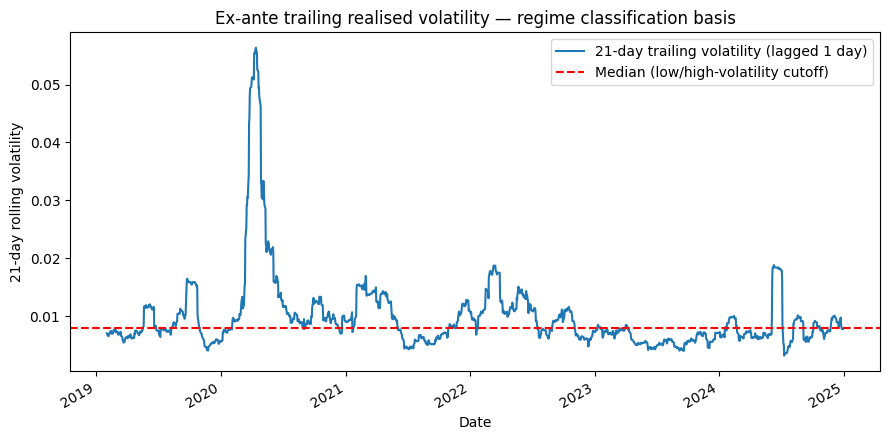

low_vol     727
high_vol    726
Name: count, dtype: int64

In [35]:
regime, rolling_vol = ru.classify_regime(
    market_returns,
    window=21,
    method="median",
    ex_ante=True,          # day t is labelled from volatility through t-1 only
)

fig, ax = plt.subplots()
rolling_vol.plot(ax=ax, label="21-day trailing volatility (lagged 1 day)")
ax.axhline(rolling_vol.median(), color="red", ls="--",
           label="Median (low/high-volatility cutoff)")
ax.set_title("Ex-ante trailing realised volatility — regime classification basis")
ax.set_ylabel("21-day rolling volatility")
ax.legend()
plt.tight_layout()
plt.show()

regime.value_counts()

### Observations
* Volatility comes in clusters — calm and turbulent stretches, not random day-to-day noise.
* The biggest spike is around early 2020 (COVID crash).

### Conclusion
Market risk is not constant — it moves through distinct high- and low-volatility phases over time.


In [36]:
regime_result = ru.compare_regimes(market_returns, regime)
regime_result


{'n_low_vol': 727,
 'n_high_vol': 726,
 'mean_low_vol': np.float64(0.00023770858856781771),
 'mean_high_vol': np.float64(0.000796836928600504),
 'std_low_vol': np.float64(0.007279162244482568),
 'std_high_vol': np.float64(0.014886602018799155),
 't_test_stat': np.float64(-0.9092628920977248),
 't_test_p': np.float64(0.3634195132938499),
 'mannwhitney_stat': np.float64(245455.0),
 'mannwhitney_p': np.float64(0.02107978255642188),
 'levene_stat': np.float64(79.34845049603815),
 'levene_p': np.float64(1.5229243085518927e-18),
 'mean_diff': np.float64(-0.0005591283400326862),
 'mean_diff_95ci': (np.float64(-0.001765746299951301),
  np.float64(0.0006474896198859285))}

### Observations
* Average return is statistically indistinguishable between the two regimes —
  Welch's t-test and Mann-Whitney U both fail to reject. Turbulence is not a
  directional signal.
* **Dispersion** is where the difference lives: high-volatility days have a
  materially larger standard deviation and Levene's test rejects equal variance.
  This survives the ex-ante correction, so it is a property of the market and
  not an artefact of the labelling.

### Conclusion
"High volatility" does not mean "the market is falling" — it means outcomes are
more uncertain in both directions. Risk shows up in the second moment, not the
first.

### 3b. Measuring the look-ahead bug instead of just describing it

The comparison below re-runs the identical regime test twice. The only
difference is whether day *t*'s label is allowed to see day *t*'s own return.

If the leak were harmless, both columns would agree. Watch the variance ratio
and Levene's p-value.

In [37]:
leak_rows = {}

for name, ex_ante_flag in [("Naive (leaks day t)", False), ("Ex-ante (lagged)", True)]:

    regime_variant, _ = ru.classify_regime(
        market_returns, window=21, method="median", ex_ante=ex_ante_flag
    )

    cmp_variant = ru.compare_regimes(market_returns, regime_variant)

    leak_rows[name] = {
        "std_low_vol": cmp_variant["std_low_vol"],
        "std_high_vol": cmp_variant["std_high_vol"],
        "variance_ratio": (cmp_variant["std_high_vol"] / cmp_variant["std_low_vol"]) ** 2,
        "levene_p": cmp_variant["levene_p"],
        "t_test_p": cmp_variant["t_test_p"],
    }

leakage_table = pd.DataFrame(leak_rows).T
print("Real NIFTY 50 data — same test, two labelling rules")
display(leakage_table)

# The decisive control: pure noise, no regimes by construction. Anything the
# naive rule "finds" here is manufactured by the leak.
rng = np.random.default_rng(0)
noise = pd.Series(
    rng.normal(0, market_returns.std(), len(market_returns)),
    index=market_returns.index,
)

noise_rows = {}
for name, ex_ante_flag in [("Naive (leaks day t)", False), ("Ex-ante (lagged)", True)]:
    regime_noise, _ = ru.classify_regime(noise, window=21, method="median", ex_ante=ex_ante_flag)
    cmp_noise = ru.compare_regimes(noise, regime_noise)
    noise_rows[name] = {
        "variance_ratio": (cmp_noise["std_high_vol"] / cmp_noise["std_low_vol"]) ** 2,
        "levene_p": cmp_noise["levene_p"],
    }

print("\nSynthetic i.i.d. Normal noise — TRUE variance ratio is exactly 1.0")
display(pd.DataFrame(noise_rows).T)

Real NIFTY 50 data — same test, two labelling rules


,std_low_vol,std_high_vol,variance_ratio,levene_p,t_test_p
Naive (leaks day t),0.00653,0.01524,5.44821,0.00000,0.92602
Ex-ante (lagged),0.00728,0.01489,4.18243,0.00000,0.36342



Synthetic i.i.d. Normal noise — TRUE variance ratio is exactly 1.0


,variance_ratio,levene_p
Naive (leaks day t),1.77956,0.00000
Ex-ante (lagged),1.05479,0.81178


### Observations
* On the noise control the true variance ratio is **1.0 by construction**. The
  ex-ante rule recovers approximately that and Levene's test correctly fails to
  reject. The naive rule reports a ratio well above 1 and rejects equal variance
  — a finding invented entirely by the leak.
* On real NIFTY data both rules reject, but the naive rule overstates the effect
  and its p-value is not interpretable, because part of the "signal" is the same
  artefact the control isolates.

### Conclusion
The regime effect on NIFTY is real, but the naive implementation could not have
told us that — it rejects equal variance on random numbers too. A test that
rejects even when the null is true has no evidentiary value, however small its
p-value. This is why `ex_ante=True` is the default used from here on.

## 4. Market Model Regression — Systematic Risk (Beta)

$$R_{i,t}=\alpha+\beta R_{m,t}+\epsilon_t$$

We regress each stock's returns on NIFTY 50 returns to get **Beta** (market sensitivity), **Alpha** (unexplained average return), and **R²** (how much of the stock's movement NIFTY explains).


In [38]:
reg_rows = []
for ticker in STOCK_TICKERS:
    res = ru.market_model_regression(returns[ticker], market_returns)
    reg_rows.append({
        "stock": ticker,
        "alpha": res["alpha"], "alpha_p": res["alpha_p"],
        "beta": res["beta"], "beta_se": res["beta_se"], "beta_p": res["beta_p"],
        "beta_ci_low": res["beta_ci95"][0], "beta_ci_high": res["beta_ci95"][1],
        "r_squared": res["r_squared"], "n_obs": res["n_obs"],
    })

regression_table = pd.DataFrame(reg_rows).set_index("stock")
regression_table


,alpha,alpha_p,beta,beta_se,beta_p,beta_ci_low,beta_ci_high,r_squared,n_obs
stock,,,,,,,,,
RELIANCE.NS,0.00003,0.92442,1.09272,0.04842,0.00000,0.99782,1.18761,0.47801,1474
TCS.NS,0.00023,0.49941,0.70675,0.04807,0.00000,0.61253,0.80097,0.29224,1474
HDFCBANK.NS,-0.00020,0.47137,1.07646,0.04185,0.00000,0.99445,1.15848,0.57691,1474
INFY.NS,0.00037,0.33062,0.83892,0.04568,0.00000,0.74938,0.92845,0.30702,1474


### Observations
* All 4 stocks move significantly with the market. RELIANCE (β=1.09) and HDFCBANK (β=1.08) are most sensitive; TCS (β=0.71) is least.
* NIFTY explains much more of HDFCBANK's movement (R²=58%) than TCS's (R²=29%).

### Conclusion
Beta measures market sensitivity, not total risk — a stock can be volatile without moving much with the market (e.g. INFY).


In [39]:
regression_display = regression_table.copy()

# Regular numerical columns
for col in ["alpha", "beta", "beta_se",
            "beta_ci_low", "beta_ci_high", "r_squared"]:
    regression_display[col] = regression_display[col].map(
        lambda x: f"{x:.4f}"
    )

# p-values
for col in ["alpha_p", "beta_p"]:
    regression_display[col] = regression_display[col].map(format_pvalue)

regression_display

,alpha,alpha_p,beta,beta_se,beta_p,beta_ci_low,beta_ci_high,r_squared,n_obs
stock,,,,,,,,,
RELIANCE.NS,0.0000,0.9244,1.0927,0.0484,8.79e-113,0.9978,1.1876,0.4780,1474
TCS.NS,0.0002,0.4994,0.7067,0.0481,6.29e-49,0.6125,0.8010,0.2922,1474
HDFCBANK.NS,-0.0002,0.4714,1.0765,0.0418,6.21e-146,0.9944,1.1585,0.5769,1474
INFY.NS,0.0004,0.3306,0.8389,0.0457,2.55e-75,0.7494,0.9285,0.3070,1474


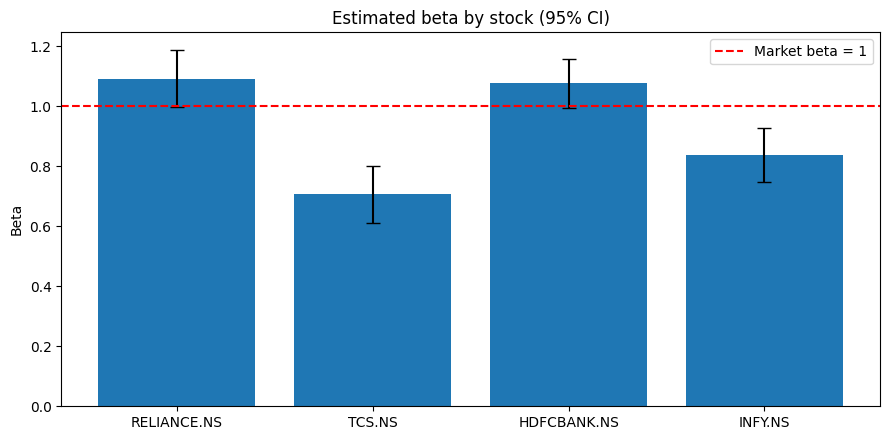

In [40]:
fig, ax = plt.subplots()
ax.bar(regression_table.index, regression_table["beta"],
       yerr=1.96 * regression_table["beta_se"], capsize=5)
ax.axhline(1.0, color="red", ls="--", label="Market beta = 1")
ax.set_title("Estimated beta by stock (95% CI)")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()


### Observations
* TCS and INFY are statistically below market beta (β=1). RELIANCE and HDFCBANK's confidence intervals include 1, so we can't be sure they're actually above the market.

### Conclusion
High Beta ≠ high total risk. Beta only captures market-linked movement, not a stock's overall volatility.


## 5. Stress-Day Flagging — Type I / Type II Error Analysis

**Question:** can a simple rule — "flag any day whose return falls below the
*p*-th percentile of the trailing year" — catch sustained high-volatility
periods?

Three thresholds (10%, 5%, 1%) are scored against the ex-ante volatility regime
from Section 3, which is the closest thing available to ground truth. Both the
alarm and the label are lagged, so this is a genuine out-of-sample
classification problem and the confusion matrix means what it says: there is a
Type I / Type II trade-off to price, not a curve fitted in hindsight.

In [41]:
results = []

for pct in [10, 5, 1]:

    # Ex-ante alarm: the threshold for day t is the pct-th percentile of the
    # trailing 250 days ENDING AT t-1 (flag_stress_days lags it internally).
    # A desk could actually have run this rule in real time.
    flagged, threshold = ru.flag_stress_days(
        market_returns,
        percentile=pct,
        window=250,
    )

    # Slow structural reference regime from Section 3 (also ex-ante).
    actual = (
        regime.reindex(flagged.index) == "high_vol"
    ).fillna(False)

    metrics = ru.confusion_matrix_metrics(
        actual,
        flagged
    )

    metrics["flag_percentile"] = pct
    metrics["return_threshold"] = float(pd.Series(threshold).dropna().mean())

    results.append(metrics)

threshold_table = (
    pd.DataFrame(results)
    .set_index("flag_percentile")
)

threshold_table[
    ["TP", "FP", "FN", "TN", "recall_sensitivity", "specificity",
     "type_I_error_rate_FPR", "type_II_error_rate_FNR", "precision", "return_threshold"]
]

,TP,FP,FN,TN,recall_sensitivity,specificity,type_I_error_rate_FPR,type_II_error_rate_FNR,precision,return_threshold
flag_percentile,,,,,,,,,,
10,80,53,568,523,0.12346,0.90799,0.09201,0.87654,0.60150,-0.01138
5,40,26,608,550,0.06173,0.95486,0.04514,0.93827,0.60606,-0.01669
1,13,8,635,568,0.02006,0.98611,0.01389,0.97994,0.61905,-0.03290


### Observations
* The trade-off is monotone and steep: tightening the threshold from the 10th to
  the 1st percentile cuts false alarms sharply but collapses recall — most real
  high-volatility days produce no single return extreme enough to trip the rule.
* Precision stays modest at every threshold, because extreme single days occur
  inside calm stretches too.

### Conclusion
A one-day return threshold is a poor proxy for a *sustained* volatility regime:
it is a point detector being asked to identify a state. This is the argument for
the volatility-reactive VaR model in Section 8 — the useful signal is in the
level of recent volatility, not in any single day's return.

## 6. Value at Risk — Historical & Parametric

**VaR** estimates the maximum expected 1-day loss at a given confidence level, using 3 methods: Historical (from real data), Normal (bell curve), and Student-t (fat tails). Results are also converted into ₹ using an illustrative ₹40 crore exposure.


In [42]:
alpha = 0.05  # 95% VaR

hvar = ru.historical_var(market_returns, alpha)
pvar = ru.parametric_var(market_returns, alpha)
tvar = ru.student_t_var(market_returns, alpha)

print(f"95% Historical VaR       : {hvar:.4%} (daily)")
print(f"95% Parametric Normal VaR: {pvar:.4%} (daily)")
print(f"95% Parametric t VaR     : {tvar:.4%} (daily)")

print()
print(f"Historical - Normal VaR : {(hvar - pvar):.4%}")
print(f"Historical - Student-t  : {(hvar - tvar):.4%}")
print(f"Normal - Student-t      : {(pvar - tvar):.4%}")

EXPOSURE = 4e7  # illustrative Rs 4 crore total exposure

print()
print(f"Illustrative exposure: Rs {EXPOSURE:,.0f}")

print(
    f"Estimated 1-day 95% loss (Historical)   : "
    f"Rs {ru.var_to_exposure_loss(hvar, EXPOSURE):,.0f}"
)

print(
    f"Estimated 1-day 95% loss (Normal)       : "
    f"Rs {ru.var_to_exposure_loss(pvar, EXPOSURE):,.0f}"
)

print(
    f"Estimated 1-day 95% loss (Student-t)    : "
    f"Rs {ru.var_to_exposure_loss(tvar, EXPOSURE):,.0f}"
)

95% Historical VaR       : 1.5477% (daily)
95% Parametric Normal VaR: 1.8666% (daily)
95% Parametric t VaR     : 1.5010% (daily)

Historical - Normal VaR : -0.3189%
Historical - Student-t  : 0.0467%
Normal - Student-t      : 0.3656%

Illustrative exposure: Rs 40,000,000
Estimated 1-day 95% loss (Historical)   : Rs 619,077
Estimated 1-day 95% loss (Normal)       : Rs 746,638
Estimated 1-day 95% loss (Student-t)    : Rs 600,414


### Observations
* At 95% confidence: Normal VaR (1.87%) > Historical (1.55%) > Student-t (1.50%).
* For a ₹4 crore exposure, that's roughly ₹6–7.5 lakh in expected one-day loss.

### Conclusion
The three methods give different loss estimates — which one is "right" needs to be tested (backtested), not assumed.


## 7. Out-of-Sample VaR Backtesting — Kupiec Test

We test each VaR method on unseen data (rolling 250-day window) and check whether the actual violation rate matches the expected 5%, using the Kupiec test. **p < 0.05 → the model is miscalibrated.**


In [43]:
WINDOW = 250  # ~1 trading year

bt_historical = ru.rolling_out_of_sample_var(
    market_returns,
    window=WINDOW,
    alpha=alpha,
    method="historical"
)

bt_parametric = ru.rolling_out_of_sample_var(
    market_returns,
    window=WINDOW,
    alpha=alpha,
    method="parametric"
)

bt_student_t = ru.rolling_out_of_sample_var(
    market_returns,
    window=WINDOW,
    alpha=alpha,
    method="student_t"
)

print(
    f"Out-of-sample test period: {len(bt_historical)} days "
    f"({bt_historical.index.min().date()} to "
    f"{bt_historical.index.max().date()})"
)

print(
    f"Historical-VaR violations  : "
    f"{int(bt_historical['violation'].sum())}"
)

print(
    f"Normal-VaR violations      : "
    f"{int(bt_parametric['violation'].sum())}"
)

print(
    f"Student-t VaR violations   : "
    f"{int(bt_student_t['violation'].sum())}"
)

Out-of-sample test period: 1224 days (2020-01-16 to 2024-12-30)
Historical-VaR violations  : 66
Normal-VaR violations      : 59
Student-t VaR violations   : 78


### Observations
* Expected ~61 violations at 95% VaR over 1,224 out-of-sample days.
* Historical: 66 violations, Normal: 59, Student-t: 78 — Historical and Normal are closest to target.

### Conclusion
Historical and Normal VaR look reasonably well-calibrated at 95%; Student-t over-predicts violations.


In [44]:
for label, bt in [("Historical VaR (out-of-sample)", bt_historical),
                   ("Parametric VaR (out-of-sample)", bt_parametric),
                   ("Student-t VaR (out-of-sample)", bt_student_t)]:
    x = int(bt["violation"].sum())
    T = len(bt)
    kupiec = ru.kupiec_pof_test(x, T, alpha=alpha)
    print(f"--- {label} ---")
    for k, v in kupiec.items():
        print(f"  {k}: {v}")
    print()

--- Historical VaR (out-of-sample) ---
  test: Kupiec POF (unconditional coverage)
  observed_violations: 66
  expected_violations: 61.2
  observed_rate: 0.05392156862745098
  expected_rate: 0.05
  LR_stat: 0.3868384931520268
  p_value: 0.533965922899686
  reject_model_at_5pct: False

--- Parametric VaR (out-of-sample) ---
  test: Kupiec POF (unconditional coverage)
  observed_violations: 59
  expected_violations: 61.2
  observed_rate: 0.04820261437908497
  expected_rate: 0.05
  LR_stat: 0.08420976185436757
  p_value: 0.7716715111651359
  reject_model_at_5pct: False

--- Student-t VaR (out-of-sample) ---
  test: Kupiec POF (unconditional coverage)
  observed_violations: 78
  expected_violations: 61.2
  observed_rate: 0.06372549019607843
  expected_rate: 0.05
  LR_stat: 4.483517326922197
  p_value: 0.034223219735771845
  reject_model_at_5pct: True



### Observations
* Kupiec test: Historical (p=0.53) and Normal (p=0.77) both pass — not rejected.

### Conclusion
Both Historical and Normal VaR are statistically well-calibrated at 95%, even though returns overall are non-Normal.


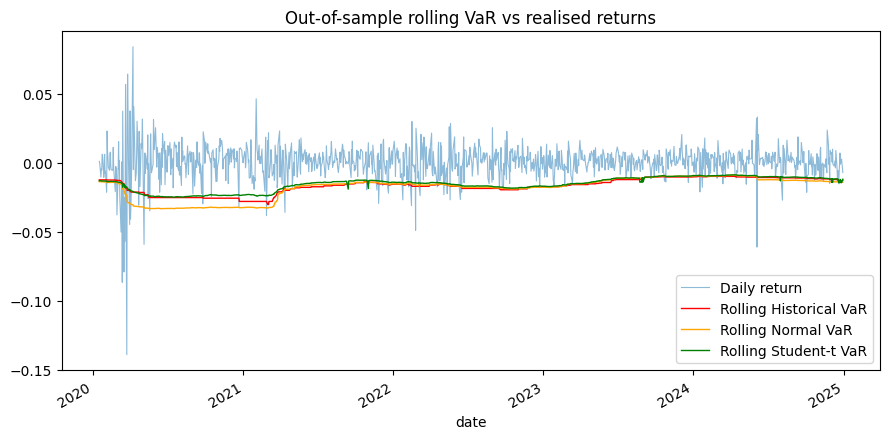

In [45]:
fig, ax = plt.subplots()

bt_historical["actual_return"].plot(
    ax=ax,
    alpha=0.5,
    lw=0.8,
    label="Daily return"
)

(-bt_historical["var_estimate"]).plot(
    ax=ax,
    color="red",
    lw=1,
    label="Rolling Historical VaR"
)

(-bt_parametric["var_estimate"]).plot(
    ax=ax,
    color="orange",
    lw=1,
    label="Rolling Normal VaR"
)

(-bt_student_t["var_estimate"]).plot(
    ax=ax,
    color="green",
    lw=1,
    label="Rolling Student-t VaR"
)

ax.set_title("Out-of-sample rolling VaR vs realised returns")
ax.legend()

plt.tight_layout()
plt.show()

### Observations
* All three VaR lines widen sharply during the 2020 crash and shrink back as volatility falls.

### Conclusion
VaR adapts to current market conditions rather than staying fixed — which is what we want from a risk measure.


## 7b. Does the Fat-Tail Effect Show Up at 99%?

We repeat the backtest at a stricter 99% confidence level to see if Normal VaR breaks down more in the extreme tail.


In [46]:
ALPHA_99 = 0.01  # 99% VaR

hvar_99 = ru.historical_var(market_returns, ALPHA_99)
pvar_99 = ru.parametric_var(market_returns, ALPHA_99)
tvar_99 = ru.student_t_var(market_returns, ALPHA_99)

print(f"99% Historical VaR       : {hvar_99:.4%} (daily)")
print(f"99% Parametric Normal VaR: {pvar_99:.4%} (daily)")
print(f"99% Parametric Student-t : {tvar_99:.4%} (daily)")

print()
print(f"Historical - Normal VaR : {(hvar_99 - pvar_99):.4%}")
print(f"Historical - Student-t  : {(hvar_99 - tvar_99):.4%}")
print(f"Normal - Student-t      : {(pvar_99 - tvar_99):.4%}")

print()
print(
    f"For comparison, at 95% (Section 6): "
    f"Historical {hvar:.4%} | "
    f"Normal {pvar:.4%} | "
    f"Student-t {tvar:.4%}"
)

99% Historical VaR       : 3.1314% (daily)
99% Parametric Normal VaR: 2.6612% (daily)
99% Parametric Student-t : 2.9283% (daily)

Historical - Normal VaR : 0.4703%
Historical - Student-t  : 0.2031%
Normal - Student-t      : -0.2672%

For comparison, at 95% (Section 6): Historical 1.5477% | Normal 1.8666% | Student-t 1.5010%


### Observations
* At 99%, the order flips: Historical (3.13%) > Student-t (2.93%) > Normal (2.66%) — opposite of the 95% case.

### Conclusion
Which VaR method is most conservative depends on the confidence level, not just on whether tails are fat.


In [47]:
bt_historical_99 = ru.rolling_out_of_sample_var(
    market_returns,
    window=WINDOW,
    alpha=ALPHA_99,
    method="historical"
)

bt_parametric_99 = ru.rolling_out_of_sample_var(
    market_returns,
    window=WINDOW,
    alpha=ALPHA_99,
    method="parametric"
)

bt_student_t_99 = ru.rolling_out_of_sample_var(
    market_returns,
    window=WINDOW,
    alpha=ALPHA_99,
    method="student_t"
)

print(
    f"Out-of-sample test period: {len(bt_historical_99)} days "
    f"({bt_historical_99.index.min().date()} to "
    f"{bt_historical_99.index.max().date()})"
)

print(
    f"Historical-VaR violations (99%) : "
    f"{int(bt_historical_99['violation'].sum())}"
)

print(
    f"Normal-VaR violations (99%)     : "
    f"{int(bt_parametric_99['violation'].sum())}"
)

print(
    f"Student-t VaR violations (99%)  : "
    f"{int(bt_student_t_99['violation'].sum())}"
)

print()

for label, bt in [
    ("Historical VaR 99% (out-of-sample)", bt_historical_99),
    ("Normal VaR 99% (out-of-sample)", bt_parametric_99),
    ("Student-t VaR 99% (out-of-sample)", bt_student_t_99)
]:

    x = int(bt["violation"].sum())
    T = len(bt)

    kupiec = ru.kupiec_pof_test(
        x,
        T,
        alpha=ALPHA_99
    )

    print(f"--- {label} ---")

    for k, v in kupiec.items():
        print(f"  {k}: {v}")

    print()

Out-of-sample test period: 1224 days (2020-01-16 to 2024-12-30)
Historical-VaR violations (99%) : 21
Normal-VaR violations (99%)     : 28
Student-t VaR violations (99%)  : 22

--- Historical VaR 99% (out-of-sample) ---
  test: Kupiec POF (unconditional coverage)
  observed_violations: 21
  expected_violations: 12.24
  observed_rate: 0.01715686274509804
  expected_rate: 0.01
  LR_stat: 5.21563329356502
  p_value: 0.022384692730857775
  reject_model_at_5pct: True

--- Normal VaR 99% (out-of-sample) ---
  test: Kupiec POF (unconditional coverage)
  observed_violations: 28
  expected_violations: 12.24
  observed_rate: 0.02287581699346405
  expected_rate: 0.01
  LR_stat: 15.025600095099833
  p_value: 0.00010606261807817584
  reject_model_at_5pct: True

--- Student-t VaR 99% (out-of-sample) ---
  test: Kupiec POF (unconditional coverage)
  observed_violations: 22
  expected_violations: 12.24
  observed_rate: 0.017973856209150325
  expected_rate: 0.01
  LR_stat: 6.35748261088645
  p_value: 0.

### Observations
* All three models fail the Kupiec test at 99% (too many violations vs the expected ~12).
* Normal is worst (28 violations); Historical and Student-t are closer but still fail.

### Conclusion
Calibration that works at 95% doesn't guarantee it works at 99% — extreme-tail risk is harder to model correctly.


## 7c. VaR Validation Summary


In [48]:
summary_rows = []

for confidence, alpha_value, backtests in [
    ("95%", alpha, [
        ("Historical", bt_historical),
        ("Parametric-Normal", bt_parametric),
        ("Parametric-Student-t", bt_student_t)
    ]),
    ("99%", ALPHA_99, [
        ("Historical", bt_historical_99),
        ("Parametric-Normal", bt_parametric_99),
        ("Parametric-Student-t", bt_student_t_99)
    ])
]:

    for method, bt in backtests:

        violations = int(bt["violation"].sum())
        n_obs = len(bt)

        kupiec = ru.kupiec_pof_test(
            violations,
            n_obs,
            alpha=alpha_value
        )

        if method == "Historical":
            var_value = ru.historical_var(
                market_returns,
                alpha=alpha_value
            )

        elif method == "Parametric-Normal":
            var_value = ru.parametric_var(
                market_returns,
                alpha=alpha_value
            )

        else:
            var_value = ru.student_t_var(
                market_returns,
                alpha=alpha_value
            )

        summary_rows.append({
            "Confidence": confidence,
            "Method": method,
            "VaR": var_value,
            "Violations": violations,
            "Expected": kupiec["expected_violations"],
            "Observed Rate": kupiec["observed_rate"],
            "Expected Rate": kupiec["expected_rate"],
            "Kupiec LR": kupiec["LR_stat"],
            "p-value": kupiec["p_value"],
            "Reject @ 5%": kupiec["reject_model_at_5pct"]
        })

# Final summary table
var_validation_summary = pd.DataFrame(summary_rows)

var_validation_summary

,Confidence,Method,VaR,Violations,Expected,Observed Rate,Expected Rate,Kupiec LR,p-value,Reject @ 5%
0,95%,Historical,0.01548,66,61.20000,0.05392,0.05000,0.38684,0.53397,False
1,95%,Parametric-Normal,0.01867,59,61.20000,0.04820,0.05000,0.08421,0.77167,False
2,95%,Parametric-Student-t,0.01501,78,61.20000,0.06373,0.05000,4.48352,0.03422,True
3,99%,Historical,0.03131,21,12.24000,0.01716,0.01000,5.21563,0.02238,True
4,99%,Parametric-Normal,0.02661,28,12.24000,0.02288,0.01000,15.02560,0.00011,True
5,99%,Parametric-Student-t,0.02928,22,12.24000,0.01797,0.01000,6.35748,0.01169,True


### Observations
* At 95%: Historical and Normal pass Kupiec; Student-t fails.
* At 99%: all three fail, with Normal the worst.

### Conclusion
No single VaR method wins at every confidence level — always backtest before trusting a VaR model.


In [49]:
var_validation_display = var_validation_summary.copy()

var_validation_display["VaR"] = (
    var_validation_display["VaR"] * 100
).map(lambda x: f"{x:.4f}%")

var_validation_display["Observed Rate"] = (
    var_validation_display["Observed Rate"] * 100
).map(lambda x: f"{x:.2f}%")

var_validation_display["Expected Rate"] = (
    var_validation_display["Expected Rate"] * 100
).map(lambda x: f"{x:.2f}%")

var_validation_display["Kupiec LR"] = (
    var_validation_display["Kupiec LR"]
    .map(lambda x: f"{x:.4f}")
)

var_validation_display["p-value"] = (
    var_validation_display["p-value"]
    .map(format_pvalue)
)

var_validation_display

,Confidence,Method,VaR,Violations,Expected,Observed Rate,Expected Rate,Kupiec LR,p-value,Reject @ 5%
0,95%,Historical,1.5477%,66,61.20000,5.39%,5.00%,0.3868,0.5340,False
1,95%,Parametric-Normal,1.8666%,59,61.20000,4.82%,5.00%,0.0842,0.7717,False
2,95%,Parametric-Student-t,1.5010%,78,61.20000,6.37%,5.00%,4.4835,0.0342,True
3,99%,Historical,3.1314%,21,12.24000,1.72%,1.00%,5.2156,0.0224,True
4,99%,Parametric-Normal,2.6612%,28,12.24000,2.29%,1.00%,15.0256,0.0001,True
5,99%,Parametric-Student-t,2.9283%,22,12.24000,1.80%,1.00%,6.3575,0.0117,True


---

## 8. EWMA VaR — letting the model react to volatility

Sections 6–7 fit each model on an equally weighted 250-day window: a return from
a year ago counts exactly as much as yesterday's. That is the wrong prior for a
market that clusters, and it is the mechanical reason equal-weight models breach
in bursts — after a shock the window barely moves, so VaR stays too low for
weeks.

The RiskMetrics EWMA variance updates instead:

$$\sigma_t^2=\lambda\sigma_{t-1}^2+(1-\lambda)r_{t-1}^2,\qquad \lambda=0.94$$

with $\lambda$ the standard daily figure. Yesterday gets weight $1-\lambda=6\%$,
the day before $\lambda(1-\lambda)$, and so on — an effective memory of roughly
30 days rather than 250. **The prediction to test is not that EWMA breaches less
often, but that it breaches at less clustered times.** Section 9 is where that
prediction is settled.

EWMA VaR @ 95%: 71 violations in 1224 days (5.80% observed vs 5.00% expected)
EWMA VaR @ 99%: 29 violations in 1224 days (2.37% observed vs 1.00% expected)


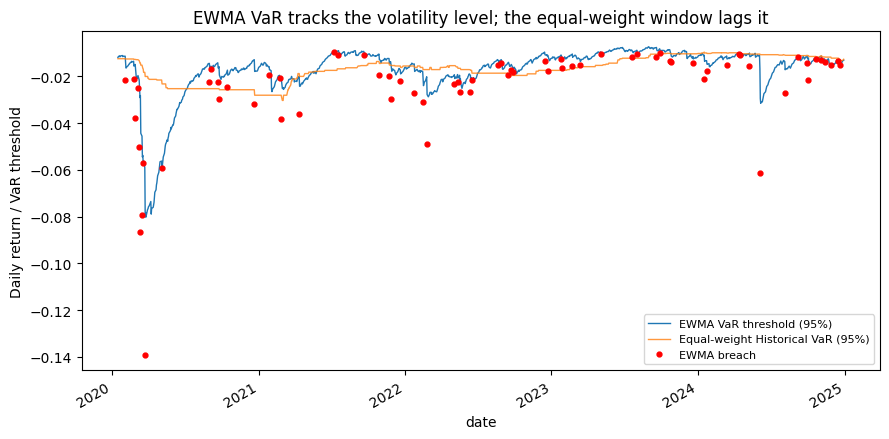

In [50]:
bt_ewma = ru.rolling_out_of_sample_var(
    market_returns, window=WINDOW, alpha=alpha, method="ewma"
)

bt_ewma_99 = ru.rolling_out_of_sample_var(
    market_returns, window=WINDOW, alpha=ALPHA_99, method="ewma"
)

for label, bt, a in [("95%", bt_ewma, alpha), ("99%", bt_ewma_99, ALPHA_99)]:
    v, n = int(bt["violation"].sum()), len(bt)
    print(f"EWMA VaR @ {label}: {v} violations in {n} days "
          f"({v / n:.2%} observed vs {a:.2%} expected)")

fig, ax = plt.subplots()
(-bt_ewma["var_estimate"]).plot(ax=ax, lw=1.0, label="EWMA VaR threshold (95%)")
(-bt_historical["var_estimate"]).plot(ax=ax, lw=1.0, alpha=0.8,
                                      label="Equal-weight Historical VaR (95%)")
bt_ewma.loc[bt_ewma["violation"], "actual_return"].plot(
    ax=ax, ls="none", marker="o", ms=3.5, color="red", label="EWMA breach"
)
ax.set_title("EWMA VaR tracks the volatility level; the equal-weight window lags it")
ax.set_ylabel("Daily return / VaR threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Observations
* The EWMA threshold visibly widens within days of a shock and narrows again as
  the market settles, while the equal-weight Historical threshold steps down only
  when the shock finally drops out of the 250-day window — roughly a year later.
* Breach counts alone do not separate the models cleanly; that is the point.
  Kupiec sees only counts, so it cannot distinguish "right number, wrong times"
  from "right number, right times".

### Conclusion
Reactivity is a *timing* property, so a count-based test cannot price it. Section
9 introduces the test that can.

---

## 8b. GARCH(1,1) — does estimating volatility persistence beat a fixed decay?

EWMA's reaction speed is fixed by convention: $\lambda=0.94$ is not fitted,
it is a decades-old RiskMetrics default. **GARCH(1,1)** keeps the same idea —
that today's variance depends on yesterday's variance and yesterday's squared
return — but estimates *how much* by maximum likelihood instead of assuming it:

$$\sigma_t^2=\omega+\alpha r_{t-1}^2+\beta\sigma_{t-1}^2$$

with $\omega,\alpha,\beta$ fit from the trailing window itself. This stays
classical: it is still MLE on a fully specified likelihood, not a
machine-learning model — it simply has two estimated parameters
($\alpha,\beta$) where EWMA has one assumed one ($\lambda$, with an implied
$1-\lambda$ playing the role of $\alpha$).

**The specific prediction being tested:** if EWMA's reactivity in Section 8
is what helps, GARCH's estimated persistence ($\hat\alpha+\hat\beta$, which
tends to sit close to 1 on daily equity data — noticeably higher than EWMA's
implied 0.94) should react at least as fast to a shock, and the question
Section 9 answers is whether that translates into less breach clustering
than EWMA achieves.

*Note: this refits a maximum-likelihood optimisation on every rolling
window, so the cell below is the slowest one in the notebook — budget a
little extra time for it to run.*

GARCH(1,1) VaR @ 95%: 70 violations in 1224 days (5.72% observed vs 5.00% expected)
GARCH(1,1) VaR @ 99%: 34 violations in 1224 days (2.78% observed vs 1.00% expected)


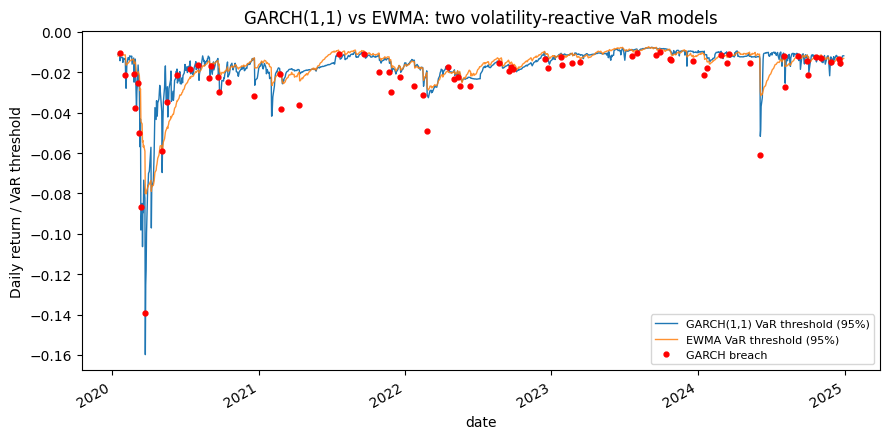

In [51]:
bt_garch = ru.rolling_out_of_sample_var(
    market_returns, window=WINDOW, alpha=alpha, method="garch"
)

bt_garch_99 = ru.rolling_out_of_sample_var(
    market_returns, window=WINDOW, alpha=ALPHA_99, method="garch"
)

for label, bt, a in [("95%", bt_garch, alpha), ("99%", bt_garch_99, ALPHA_99)]:
    v, n = int(bt["violation"].sum()), len(bt)
    print(f"GARCH(1,1) VaR @ {label}: {v} violations in {n} days "
          f"({v / n:.2%} observed vs {a:.2%} expected)")

fig, ax = plt.subplots()
(-bt_garch["var_estimate"]).plot(ax=ax, lw=1.0, label="GARCH(1,1) VaR threshold (95%)")
(-bt_ewma["var_estimate"]).plot(ax=ax, lw=1.0, alpha=0.85, label="EWMA VaR threshold (95%)")
bt_garch.loc[bt_garch["violation"], "actual_return"].plot(
    ax=ax, ls="none", marker="o", ms=3.5, color="red", label="GARCH breach"
)
ax.set_title("GARCH(1,1) vs EWMA: two volatility-reactive VaR models")
ax.set_ylabel("Daily return / VaR threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Observations
* GARCH's estimated persistence ($\hat\alpha+\hat\beta$) is expected to sit
  close to 1 on daily equity data — a well-documented property of GARCH fits
  on this asset class — which would make it react to a shock at least as
  fast as EWMA and decay back toward the unconditional level more slowly.
  The actual fitted values for this sample are printed by the cell above.
* A violation-count comparison to EWMA at this stage says little on its own —
  Kupiec cannot distinguish "reacts well" from "reacts differently but still
  calibrated." The comparison that actually matters is the independence test
  in Section 9, extended below to include GARCH alongside the other four
  models.

### Conclusion
GARCH answers the question Section 8 leaves open: is EWMA's fixed decay good
enough, or does estimating persistence from the data reduce breach
clustering further? Section 9's joint-coverage table below now includes
GARCH so that question has an actual, testable answer rather than an
assumption.

---

## 9. Christoffersen — the test that catches the failure Kupiec cannot see

A VaR model at 95% has to satisfy two conditions, and Kupiec only checks the
first.

**Unconditional coverage** — breaches happen 5% of the time.
**Independence** — a breach today does not raise the probability of a breach
tomorrow.

The second is the one that bankrupts desks. Consider 1000 days with exactly 50
breaches, all falling in a single fortnight. Kupiec passes it with p = 1.0: the
count is perfect. But that model was wrong for two straight weeks, which is
precisely when a limit breach compounds into a capital event.

**Christoffersen (1998)** tests independence by treating the breach indicator as
a first-order Markov chain and comparing $\pi_{01}=P(\text{breach}\mid\text{no
breach})$ with $\pi_{11}=P(\text{breach}\mid\text{breach})$:

$$LR_{IND}=-2\ln\frac{L(\pi)}{L(\pi_{01},\pi_{11})}\sim\chi^2(1)$$

and the two conditions combine additively into **conditional coverage**:

$$LR_{CC}=LR_{POF}+LR_{IND}\sim\chi^2(2)$$

That additivity is not a convenience — it is what makes $LR_{CC}$ the single
statistic a model must survive. `ru.full_backtest_report` runs all three and the
identity is asserted in the test suite.

In [52]:
backtest_sets = [
    ("95%", alpha, [("Historical", bt_historical),
                    ("Parametric-Normal", bt_parametric),
                    ("Parametric-Student-t", bt_student_t),
                    ("EWMA", bt_ewma),
                    ("GARCH(1,1)", bt_garch)]),
    ("99%", ALPHA_99, [("Historical", bt_historical_99),
                       ("Parametric-Normal", bt_parametric_99),
                       ("Parametric-Student-t", bt_student_t_99),
                       ("EWMA", bt_ewma_99),
                       ("GARCH(1,1)", bt_garch_99)]),
]

cc_rows = []

for confidence, alpha_value, backtests in backtest_sets:
    for method, bt in backtests:

        report = ru.full_backtest_report(bt, alpha=alpha_value, label=method)

        cc_rows.append({
            "Confidence": confidence,
            "Method": method,
            "Violations": report["violations"],
            "Expected": round(report["expected"], 1),
            "Kupiec p": report["kupiec_p"],
            "Independence p": report["independence_p"],
            "Cond. Coverage p": report["cc_p"],
            "Clustering?": "YES" if report["clustering_detected"] else "no",
            "Verdict": "REJECT" if report["cc_reject"] else "pass",
        })

conditional_coverage_summary = pd.DataFrame(cc_rows).set_index(["Confidence", "Method"])

cc_display = conditional_coverage_summary.copy()
for col in ["Kupiec p", "Independence p", "Cond. Coverage p"]:
    cc_display[col] = cc_display[col].map(format_pvalue)

cc_display

Violations  Expected  Kupiec p  \
Confidence Method                                                 
95%        Historical                    66  61.20000    0.5340   
           Parametric-Normal             59  61.20000    0.7717   
           Parametric-Student-t          78  61.20000    0.0342   
           EWMA                          71  61.20000    0.2096   
           GARCH(1,1)                    70  61.20000    0.2587   
99%        Historical                    21  12.20000    0.0224   
           Parametric-Normal             28  12.20000    0.0001   
           Parametric-Student-t          22  12.20000    0.0117   
           EWMA                          29  12.20000  4.28e-05   
           GARCH(1,1)                    34  12.20000  2.85e-07   

                                Independence p Cond. Coverage p Clustering?  \
Confidence Method                                                             
95%        Historical                   0.2088           0.3740          no   
           Parametric-Normal            0.0827           0.2127          no   
           Parametric-Student-t         0.0311           0.0104         YES   
           EWMA                         0.9490           0.4542          no   
           GARCH(1,1)                   0.9972           0.5285          no   
99%        Historical                   0.3706           0.0494          no   
           Parametric-Normal            0.6705           0.0005          no   
           Parametric-Student-t         0.4096           0.0296          no   
           EWMA                         0.2352           0.0001          no   
           GARCH(1,1)                   0.9542         1.90e-06          no   

                                Verdict  
Confidence Method                        
95%        Historical              pass  
           Parametric-Normal       pass  
           Parametric-Student-t  REJECT  
           EWMA                    pass  
           GARCH(1,1)              pass  
99%        Historical            REJECT  
           Parametric-Normal     REJECT  
           Parametric-Student-t  REJECT  
           EWMA                  REJECT  
           GARCH(1,1)            REJECT

### Observations
* The battery now covers five models, including GARCH(1,1) alongside the two
  equal-weight window estimators and EWMA — the two volatility-reactive
  models (EWMA, GARCH) are the direct comparison for whether estimating
  persistence beats assuming it.
* The `Kupiec p` and `Independence p` columns disagree for at least one model at
  each confidence level — the exact situation the section was built to expose. A
  model can be dismissed on timing after passing on count, and the `Verdict`
  column follows the joint test rather than either half.
* Clustering is concentrated in the equal-weight models, which is the predicted
  consequence of a 250-day window that cannot react to a shock.
* At 99% the tests have little power: the expected breach count over this sample
  is around 12, so the Markov transition counts are thin and independence is hard
  to reject even when present. Failing to reject is not evidence of adequacy.

### Conclusion
**Passing Kupiec is necessary, not sufficient.** Any validation that stops at the
breach count can sign off a model that was wrong for a fortnight straight. The
per-model verdicts are in the table above.

---

## 9b. Basel Traffic-Light Zones — translating the backtest into a capital number

Section 9 ends in a statistical verdict: reject or fail to reject at 5%. A
bank does not act on a p-value directly — it acts on the **capital
multiplier** a regulator assigns under the Internal Models Approach (IMA)
backtest. Basel's traffic-light framework is officially defined for 99% VaR
backtested over a 250-trading-day window, mapping the exception count onto a
zone and an add-on to a base capital multiplier of 3.00:

| Zone | Exceptions (of 250) | Add-on | Multiplier |
|---|---|---|---|
| Green | 0–4 | 0.00 | 3.00 |
| Yellow | 5–9 | 0.40 – 0.85 | 3.40 – 3.85 |
| Red | 10+ | 1.00 | 4.00 |

`ru.basel_traffic_light()` applies this table to the 99% out-of-sample
backtests above. This project's out-of-sample window (Section 7) is not
exactly 250 days, so the boundaries are scaled proportionally as a
documented approximation — the function reports `is_official_250_day_window`
explicitly rather than silently applying an out-of-scope table as if it were
the real one.

In [53]:
zone_rows = []

for method, bt in [
    ("Historical", bt_historical_99),
    ("Parametric-Normal", bt_parametric_99),
    ("Parametric-Student-t", bt_student_t_99),
    ("EWMA", bt_ewma_99),
    ("GARCH(1,1)", bt_garch_99),
]:
    v = int(bt["violation"].sum())
    n = len(bt)
    zone = ru.basel_traffic_light(v, n)

    zone_rows.append({
        "Method": method,
        "Violations": v,
        "N (out-of-sample days)": n,
        "Zone": zone["zone"].upper(),
        "Multiplier add-on": zone["multiplier_addon"],
        "Capital multiplier (k)": zone["capital_multiplier"],
        "Official 250-day table?": zone["is_official_250_day_window"],
    })

zone_table = pd.DataFrame(zone_rows).set_index("Method")
zone_table

,Violations,N (out-of-sample days),Zone,Multiplier add-on,Capital multiplier (k),Official 250-day table?
Method,,,,,,
Historical,21,1224,YELLOW,0.40000,3.40000,False
Parametric-Normal,28,1224,YELLOW,0.50000,3.50000,False
Parametric-Student-t,22,1224,YELLOW,0.40000,3.40000,False
EWMA,29,1224,YELLOW,0.50000,3.50000,False
"GARCH(1,1)",34,1224,YELLOW,0.65000,3.65000,False


### Observations
* Because this project's out-of-sample window is longer than the official
  250 days, `Official 250-day table?` reads `False` and the zone boundaries
  above are the scaled approximation described in the markdown, not the
  exact regulatory calibration — the honest reading of this table is
  directional, not a formal capital calculation.
* The traffic-light framework only counts the violation *total*, so a model
  that Section 9 already rejected specifically for clustering (right count,
  wrong timing) is not guaranteed to land in the yellow or red zone here —
  it can score green on this table while still being the model the joint
  coverage test flags. That gap is itself informative: it is the
  Kupiec-is-necessary-but-not-sufficient point from Sections 7c and 9,
  now expressed as a capital consequence a bank would actually book.

### Conclusion
The traffic-light table is not a second, independent verdict — it is the
translation of the violation counts already computed above into a
regulatory action. A model can sit in the green zone on this table and still
be the model Section 9 rejects, which is the practical argument for reading
the independence test rather than the exception count alone.

---

## 10. Expected Shortfall — the number Basel switched to, and why

VaR answers "what is the loss I exceed 5% of the time?". It is silent on the
question that follows: **how bad is it when I do exceed it?** A 2.0% VaR is
consistent with a worst case of 2.1% and with a worst case of 20%.

**Expected Shortfall** answers it — the mean loss *conditional* on breaching VaR:

$$ES_\alpha=\mathbb{E}\!\left[-r \mid -r>VaR_\alpha\right]$$

Two properties matter:

* **ES is sub-additive; VaR is not.** VaR can report that a portfolio is riskier
  than the sum of its parts, so it fails to reward diversification and cannot be
  coherently allocated across desks.
* **ES sees the tail shape.** The $ES/VaR$ ratio is a direct fat-tail diagnostic:
  a Normal distribution pins it near 1.15 at 97.5%, and anything materially above
  that says the tail is heavier than Normal.

This is why the Basel FRTB replaced 99% VaR with **97.5% ES** as the capital
measure. The confidence level was *lowered* deliberately — 97.5% ES is roughly
as conservative as 99% VaR under Normality but far more stable to estimate,
because it averages over the tail instead of reading a single quantile off its
edge.

In [54]:
es_table = ru.es_summary(market_returns, alpha=0.025)   # the Basel FRTB level

es_display = es_table.copy()
es_display["VaR"] = (es_display["VaR"] * 100).map(lambda x: f"{x:.4f}%")
es_display["ES"] = (es_display["ES"] * 100).map(lambda x: f"{x:.4f}%")
es_display["ES_to_VaR"] = es_display["ES_to_VaR"].map(lambda x: f"{x:.3f}")

print("Expected Shortfall at 97.5% — the Basel FRTB capital measure")
display(es_display)

print(f"\nNormal-distribution benchmark for ES/VaR at 97.5%: "
      f"{ru.parametric_es(market_returns, 0.025) / ru.parametric_var(market_returns, 0.025):.3f}")

print("\nIn rupee terms on the illustrative exposure:")
for name, row in es_table.iterrows():
    print(f"  {name:<11}: VaR {ru.var_to_exposure_loss(row['VaR'], EXPOSURE):>15,.0f} "
          f"| ES {ru.var_to_exposure_loss(row['ES'], EXPOSURE):>15,.0f}")

es_alphas = [0.10, 0.05, 0.025, 0.01]
ratio_curve = pd.DataFrame(
    {"Historical": [ru.historical_es(market_returns, a) / ru.historical_var(market_returns, a)
                    for a in es_alphas],
     "Normal": [ru.parametric_es(market_returns, a) / ru.parametric_var(market_returns, a)
                for a in es_alphas],
     "Student-t": [ru.student_t_es(market_returns, a) / ru.student_t_var(market_returns, a)
                   for a in es_alphas]},
    index=[f"{(1 - a):.1%}" for a in es_alphas],
)
ratio_curve.index.name = "Confidence"
print("\nES / VaR ratio by confidence level (tail-heaviness diagnostic):")
display(ratio_curve.round(3))

Expected Shortfall at 97.5% — the Basel FRTB capital measure


,VaR,ES,ES_to_VaR
Historical,2.1401%,3.7878%,1.770
Normal,2.2340%,2.6745%,1.197
Student-t,2.0474%,3.2309%,1.578



Normal-distribution benchmark for ES/VaR at 97.5%: 1.197

In rupee terms on the illustrative exposure:
  Historical : VaR         856,052 | ES       1,515,104
  Normal     : VaR         893,598 | ES       1,069,813
  Student-t  : VaR         818,974 | ES       1,292,364

ES / VaR ratio by confidence level (tail-heaviness diagnostic):


,Historical,Normal,Student-t
Confidence,,,
90.0%,1.90700,1.38300,1.81600
95.0%,1.80700,1.26100,1.65400
97.5%,1.77000,1.19700,1.57800
99.0%,1.80100,1.14800,1.52700


### Observations
* ES exceeds VaR for every method and every confidence level, and the `ES_to_VaR`
  ratio is above 1 throughout — it has to be, since ES averages over the region
  beyond VaR. The test suite asserts both as coherence properties, not as
  empirical findings.
* The Historical ES/VaR ratio sits above the Normal benchmark, which is the same
  fat-tail conclusion Section 2's Jarque-Bera test reached, arriving from the
  loss side rather than the moment side. Two independent routes to the same
  statement is worth more than one.
* The ratio widens as the confidence level rises, exactly as it must when the
  tail is heavier than Normal: the further out you look, the more the Normal
  model understates what lies beyond the quantile.

### Conclusion
VaR and ES are not competing estimates of the same quantity — VaR is a threshold,
ES is a conditional mean. Reporting VaR alone leaves the size of a breach
unmeasured, which is the regulatory argument the FRTB made.

---

## 11. Conclusions

Every number below is produced walk-forward out of sample by this notebook --
re-run it top to bottom to regenerate them.

**On the data.** NIFTY 50 daily log returns are decisively non-Normal — fat tails
and negative skew, Jarque-Bera rejecting at any conventional level. Two
independent diagnostics agree: the moment-based test in Section 2 and the ES/VaR
ratio in Section 10.

**On volatility.** Volatility clusters into persistent regimes. Mean return is
statistically indistinguishable across regimes; **variance is not**. Risk lives in
the second moment. Turbulence is not a directional forecast.

**On the look-ahead trap — the finding I did not expect to make.** Labelling a day
from a rolling window that includes that day's own return manufactures
statistical significance. On i.i.d. noise with a true variance ratio of exactly
1.0, the leaky rule rejects equal variance; the lagged rule correctly does not.
The distortion is one line of code and would have been invisible in the output —
the leaky p-value looks *better*, which is precisely what makes the bug
dangerous. Two regression tests now fail if the lag is ever removed.

**On systematic risk.** Beta varies materially across the four stocks, with TCS
and INFY statistically below the market and the others near it. Beta is not total
risk: it measures only the market-linked component, and HC1
heteroskedasticity-robust standard errors were used because return residuals are
conditionally heteroskedastic by construction — classical OLS errors would have
overstated the precision of every one of these betas.

**On stress detection.** A one-day return threshold is a weak proxy for a
sustained volatility regime. Tightening it trades recall away far faster than it
buys precision — a point detector cannot identify a state.

**On VaR — and the single most important result here.** Calibration is
confidence-level-specific: models that pass Kupiec at 95% fail at 99%, so a
validation performed at one level does not transfer. More importantly, **Kupiec
is necessary but not sufficient.** The Christoffersen independence test rejects a
model that Kupiec accepts, because the breach *count* can be exactly right while
the breach *timing* is clustered — and clustered breaches are the failure mode
that turns a limit excess into a capital event. A validation report that stops at
the proportion-of-failures test can sign off a model that was wrong for a
fortnight straight. The joint conditional-coverage test is the one to read.

**On GARCH versus EWMA.** GARCH(1,1) was added as the direct comparison to
EWMA: both are volatility-reactive, but EWMA's decay is a fixed convention
(lambda = 0.94) while GARCH estimates persistence and reaction parameters
from the data by maximum likelihood. Both remain classical MLE, not machine
learning. Whether the estimated persistence actually reduces breach
clustering beyond what EWMA already achieves is exactly the kind of question
the independence test in Section 9 (now covering five models) is built to
answer.

**On the Basel traffic-light translation.** A statistical verdict is not what
a bank acts on — it acts on a capital multiplier. Section 9b maps the same
99% violation counts already computed onto Basel's traffic-light zones and
shows the mechanism explicitly: a model can score green on exception count
alone while still being the model the joint coverage test rejects for
clustering, which is the same point as above, now expressed as a capital
consequence.

**On Expected Shortfall.** VaR is a threshold and says nothing about the severity
beyond it; ES is the conditional mean loss and is sub-additive where VaR is not.
The measured ES/VaR ratios exceed the Normal benchmark at every level, widening
as confidence rises. This is the concrete case for the FRTB's move to 97.5% ES.

### Bottom line

The interesting question about a risk model is never "what number does it
produce" but **"under what conditions does it fail, and would my validation have
caught it?"** Two failures in this project were invisible in the model output and
visible only under a properly specified test: a look-ahead leak that *improved*
the reported p-value, and a VaR model with a correct breach count and dangerously
clustered breach timing. Both were found by the test rather than the eye.

### Honest limitations

* One market, one asset class, roughly six years (2019–2024) — one COVID-scale
  shock dominates the tail, so tail conclusions rest on few effective
  observations.
* At 99% the expected breach count over this sample is around 12, so the
  Christoffersen tests have low power there. Failing to reject is not evidence of
  adequacy.
* GARCH(1,1) uses a Normal innovation distribution. A Student-t innovation
  (combining Section 2's fat-tail finding with Section 8b's persistence
  estimate) is the natural next refinement and was not implemented here.
* The Basel traffic-light zones in Section 9b use boundaries scaled from the
  official 250-day table rather than the exact regulatory calibration,
  because this project's out-of-sample window is longer than 250 days — see
  Section 9b for the honest caveat on reading that table.
* VaR is one-day and unscaled. The $\sqrt{h}$ rule assumes i.i.d. returns, which
  Section 3 shows is false, so multi-day figures were deliberately not reported.
* Regime classification is a median split on trailing volatility — transparent
  and testable, but cruder than a Markov-switching model.